<a href="https://colab.research.google.com/github/Atharva0611/machine-learning/blob/main/fraud_detectClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA


In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [39]:
import pandas as pd

if 'Time' in df.columns:
    df = df.drop(columns=['Time'])


In [40]:
#seprate variables
y = df['Class']
X = df.drop(columns=['Class'])



In [41]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [42]:
#check null values
X.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [43]:
X.fillna(0, inplace=True)

In [44]:
X.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


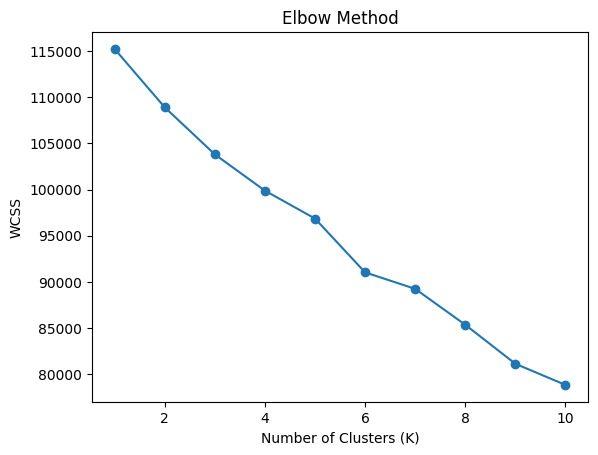

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
#elbow method
wcss = []


scaler = StandardScaler()
X_scaled_cleaned = scaler.fit_transform(X)

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(X_scaled_cleaned)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


In [46]:
k = 3


kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_cleaned)

# Silhouette Score
sil_score = silhouette_score(X_scaled_cleaned, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.08512626058991185


In [47]:
#isolation method
iso = IsolationForest(contamination=0.0017, random_state=42)
y_pred = iso.fit_predict(X_scaled)


y_pred = np.where(y_pred == -1, 1, 0)

print("Detected Fraud Cases:", sum(y_pred))

Detected Fraud Cases: 7


In [48]:
# Identify non-NaN indices in y
non_nan_indices = y.dropna().index

# Filter y and y_pred to only include non-NaN values for comparison
y_filtered = y.loc[non_nan_indices]
y_pred_filtered = y_pred[non_nan_indices]

print("\nClassification Report:")
print(classification_report(y_filtered, y_pred_filtered))

print("\nConfusion Matrix:")
print(confusion_matrix(y_filtered, y_pred_filtered))


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3970
         1.0       0.00      0.00      0.00         2

    accuracy                           1.00      3972
   macro avg       0.50      0.50      0.50      3972
weighted avg       1.00      1.00      1.00      3972


Confusion Matrix:
[[3963    7]
 [   2    0]]


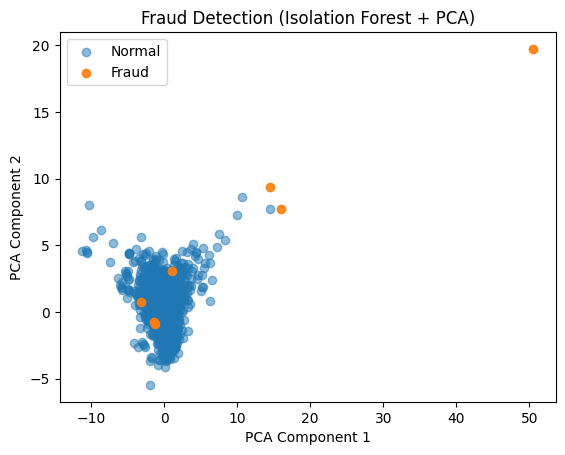

In [49]:
#pca with 2 componantes x and y
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled_cleaned)

plt.figure()

# Plot Normal first (blue)
plt.scatter(X_vis[y_pred == 0, 0], X_vis[y_pred == 0, 1],
            label="Normal", alpha=0.5)

# Plot Fraud (red)
plt.scatter(X_vis[y_pred == 1, 0], X_vis[y_pred == 1, 1],
            label="Fraud", alpha=0.9)

plt.title("Fraud Detection (Isolation Forest + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()